# 0824_kimjaehak_006_type_conditioned_baseline

Siemens AOI 데이터의 `inspection_type`별 baseline을 준비하는 실험입니다.

현재 단계에서는 전체 원본 데이터를 불러오고 기존 baseline과 동일한 기준으로 중복 행을 제거하는 과정까지만 수행합니다.

## 1. 설정과 라이브러리

실험 ID, 데이터 경로와 이후 실험에서 사용할 기본 컬럼명을 정의합니다.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0824_kimjaehak_006_type_conditioned_baseline"
RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
MODEL_PATH = Path("../models") / f"{EXPERIMENT_ID}.pkl"
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
DECISION_THRESHOLD = 0.5

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다: {DATA_PATH.resolve()}"
assert MAPPING_PATH.exists(), f"파일을 찾을 수 없습니다: {MAPPING_PATH.resolve()}"
print("experiment:", EXPERIMENT_ID)
print("pandas:", pd.__version__)

experiment: 0824_kimjaehak_006_type_conditioned_baseline
pandas: 2.3.3


## 2. 전체 원본 데이터 로딩

CSV의 첫 번째 열은 모델 피처가 아닌 익명 행 식별자입니다. 원본 파일을 수정하지 않고 해당 열의 이름만 `record_id`로 변경합니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]

if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

required_columns = {RECORD_ID, TIME_COLUMN, TYPE_COLUMN, TARGET}
missing_required_columns = required_columns - set(raw_df.columns)
assert not missing_required_columns, f"필수 컬럼 누락: {missing_required_columns}"
assert raw_df[RECORD_ID].is_unique, "record_id가 고유하지 않습니다."

pd.Series(
    {
        "rows": len(raw_df),
        "columns": raw_df.shape[1],
        "missing_cells": int(raw_df.isna().sum().sum()),
        "target_0": int((raw_df[TARGET] == 0).sum()),
        "target_1": int((raw_df[TARGET] == 1).sum()),
        "inspection_types": int(raw_df[TYPE_COLUMN].nunique()),
    },
    name="raw_data",
)

rows                440274
columns                 78
missing_cells            0
target_0            435652
target_1              4622
inspection_types         5
Name: raw_data, dtype: int64

## 3. 기존 baseline 기준 중복 행 제거

`record_id`와 `timestamp`는 중복 판단에서 제외합니다. 나머지 입력 컬럼과 타깃 `class`가 모두 같으면 중복으로 판단하고, 원본 순서에서 처음 등장한 행만 유지합니다.

In [3]:
dedup_columns = [
    column
    for column in raw_df.columns
    if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(
    subset=dedup_columns,
    keep="first",
)
duplicate_rows_removed = int(duplicate_mask.sum())

clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)

assert not clean_df.duplicated(subset=dedup_columns, keep=False).any()
assert len(clean_df) + duplicate_rows_removed == len(raw_df)

pd.Series(
    {
        "rows_before": len(raw_df),
        "duplicate_rows_removed": duplicate_rows_removed,
        "duplicate_rate_pct": duplicate_rows_removed / len(raw_df) * 100,
        "rows_after": len(clean_df),
    },
    name="deduplication",
)

rows_before               440274.000000
duplicate_rows_removed     48282.000000
duplicate_rate_pct            10.966353
rows_after                391992.000000
Name: deduplication, dtype: float64

## 4. 시간순 Train/Validation/Test 분할

기존 baseline과 동일하게 전체 행 수의 60%, 80% 지점에 가장 먼저 도달하는 timestamp를 경계로 사용합니다. 같은 timestamp의 행은 항상 같은 split에 포함됩니다.

분할은 달력 기간의 길이가 아니라 중복 제거 후 누적 행 수 기준 약 60/20/20입니다.

In [4]:
clean_df[TIME_COLUMN] = pd.to_datetime(
    clean_df[TIME_COLUMN],
    errors="raise",
    utc=True,
)
clean_df = clean_df.sort_values(
    [TIME_COLUMN, RECORD_ID],
    kind="stable",
).reset_index(drop=True)

timestamp_group_sizes = (
    clean_df[TIME_COLUMN]
    .value_counts(sort=False)
    .sort_index()
)
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

train_end_position = int(
    np.searchsorted(
        cumulative_rows,
        len(clean_df) * 0.60,
        side="left",
    )
)
valid_end_position = int(
    np.searchsorted(
        cumulative_rows,
        len(clean_df) * 0.80,
        side="left",
    )
)
train_end_time = timestamp_group_sizes.index[train_end_position]
valid_end_time = timestamp_group_sizes.index[valid_end_position]

train_mask = clean_df[TIME_COLUMN] <= train_end_time
valid_mask = (
    (clean_df[TIME_COLUMN] > train_end_time)
    & (clean_df[TIME_COLUMN] <= valid_end_time)
)
test_mask = clean_df[TIME_COLUMN] > valid_end_time

split_masks = {
    "train": train_mask,
    "validation": valid_mask,
    "test": test_mask,
}
split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": int(mask.sum()),
            "row_ratio_pct": mask.mean() * 100,
            "timestamp_groups": int(
                clean_df.loc[mask, TIME_COLUMN].nunique()
            ),
            "positive_samples": int(
                clean_df.loc[mask, TARGET].sum()
            ),
            "positive_rate_pct": (
                clean_df.loc[mask, TARGET].mean() * 100
            ),
            "start_time": clean_df.loc[mask, TIME_COLUMN].min(),
            "end_time": clean_df.loc[mask, TIME_COLUMN].max(),
        }
        for split_name, mask in split_masks.items()
    ]
).set_index("split")

assert split_summary["rows"].sum() == len(clean_df)
assert (
    clean_df.loc[train_mask, TIME_COLUMN].max()
    < clean_df.loc[valid_mask, TIME_COLUMN].min()
)
assert (
    clean_df.loc[valid_mask, TIME_COLUMN].max()
    < clean_df.loc[test_mask, TIME_COLUMN].min()
)

split_summary

,rows,row_ratio_pct,timestamp_groups,positive_samples,positive_rate_pct,start_time,end_time
split,,,,,,,
train,235222,60.006837,25501,1824,0.775438,1970-06-23 03:58:55+00:00,1970-09-28 05:48:26+00:00
validation,78374,19.993775,6282,363,0.463164,1970-09-28 05:49:10+00:00,1970-10-13 13:14:26+00:00
test,78396,19.999388,7165,2249,2.868769,1970-10-13 13:14:58+00:00,1970-11-02 14:21:28+00:00


## 5. inspection_type별 DataFrame 분리

공통 시간 경계를 유지한 상태에서 각 `inspection_type`의 Train/Validation/Test DataFrame을 생성합니다. 개별 변수 대신 `inspection_type → split → DataFrame` 구조의 중첩 딕셔너리로 관리합니다.

In [5]:
inspection_types = sorted(
    clean_df[TYPE_COLUMN].unique().tolist()
)
type_split_dfs = {}
type_split_summary_rows = []

for inspection_type in inspection_types:
    type_mask = clean_df[TYPE_COLUMN] == inspection_type
    type_split_dfs[inspection_type] = {}

    for split_name, split_mask in split_masks.items():
        combined_mask = type_mask & split_mask
        split_df = clean_df.loc[combined_mask].copy()
        type_split_dfs[inspection_type][split_name] = split_df

        type_split_summary_rows.append(
            {
                "inspection_type": inspection_type,
                "split": split_name,
                "rows": len(split_df),
                "positive_samples": int(split_df[TARGET].sum()),
                "positive_rate_pct": split_df[TARGET].mean() * 100,
                "start_time": split_df[TIME_COLUMN].min(),
                "end_time": split_df[TIME_COLUMN].max(),
            }
        )

type_split_summary = pd.DataFrame(
    type_split_summary_rows
).set_index(["inspection_type", "split"])

partitioned_rows = sum(
    len(split_df)
    for split_dfs in type_split_dfs.values()
    for split_df in split_dfs.values()
)
assert partitioned_rows == len(clean_df)
assert all(
    set(split_dfs) == set(split_masks)
    for split_dfs in type_split_dfs.values()
)

type_split_summary

rows  positive_samples  positive_rate_pct  \
inspection_type split                                                    
0               train       41961                57           0.135840   
                validation  23492                 8           0.034054   
                test        16784               133           0.792421   
1               train       34041               555           1.630387   
                validation  10494               239           2.277492   
                test        11112               784           7.055436   
2               train       74910               579           0.772928   
                validation  15897                32           0.201296   
                test        19153               703           3.670443   
3               train       80792               620           0.767403   
                validation  27328                24           0.087822   
                test        30591               603           1.971168   
4               train        3518                13           0.369528   
                validation   1163                60           5.159071   
                test          756                26           3.439153   

                                          start_time                  end_time  
inspection_type split                                                           
0               train      1970-06-23 03:58:55+00:00 1970-09-28 05:32:41+00:00  
                validation 1970-09-28 05:49:10+00:00 1970-10-13 13:02:15+00:00  
                test       1970-10-13 13:15:29+00:00 1970-11-02 14:19:05+00:00  
1               train      1970-06-23 05:00:03+00:00 1970-09-28 05:48:26+00:00  
                validation 1970-09-28 05:49:10+00:00 1970-10-13 13:12:56+00:00  
                test       1970-10-13 13:14:58+00:00 1970-11-02 14:21:28+00:00  
2               train      1970-06-23 04:01:30+00:00 1970-09-28 05:48:26+00:00  
                validation 1970-09-28 05:49:10+00:00 1970-10-13 13:13:56+00:00  
                test       1970-10-13 13:19:37+00:00 1970-11-02 14:21:28+00:00  
3               train      1970-06-23 04:00:54+00:00 1970-09-28 05:48:26+00:00  
                validation 1970-09-28 05:49:10+00:00 1970-10-13 13:14:26+00:00  
                test       1970-10-13 13:14:58+00:00 1970-11-02 14:20:42+00:00  
4               train      1970-06-24 12:16:18+00:00 1970-09-28 05:36:01+00:00  
                validation 1970-09-28 05:49:10+00:00 1970-10-13 13:13:56+00:00  
                test       1970-10-13 13:14:58+00:00 1970-11-02 12:30:10+00:00

## 6. mapping.json 기반 type별 유효 피처 구성

각 type 모델은 공통 `meta_feat`와 `mapping.json`에 정의된 해당 type의 `inspection_feat`만 사용합니다. 분기 후 상수인 `inspection_type`과 식별자, 시간, 타깃은 모델 입력에서 제외합니다.

In [6]:
with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)

assert set(feature_mapping) == {
    str(inspection_type) for inspection_type in inspection_types
}

meta_columns = [
    column
    for column in clean_df.columns
    if column.startswith("meta_feat")
]
feature_columns_by_type = {}
feature_summary_rows = []

for inspection_type in inspection_types:
    mapped_columns = feature_mapping[str(inspection_type)]
    assert len(mapped_columns) == len(set(mapped_columns))

    missing_mapped_columns = set(mapped_columns) - set(clean_df.columns)
    assert not missing_mapped_columns, (
        f"type {inspection_type} 매핑 컬럼 누락: "
        f"{sorted(missing_mapped_columns)}"
    )

    selected_columns = meta_columns + mapped_columns
    feature_columns_by_type[inspection_type] = selected_columns
    feature_summary_rows.append(
        {
            "inspection_type": inspection_type,
            "meta_features": len(meta_columns),
            "mapped_inspection_features": len(mapped_columns),
            "model_features": len(selected_columns),
        }
    )

feature_summary = pd.DataFrame(
    feature_summary_rows
).set_index("inspection_type")
feature_summary

,meta_features,mapped_inspection_features,model_features
inspection_type,,,
0,4,44,48
1,4,52,56
2,4,65,69
3,4,65,69
4,4,21,25


## 7. inspection_type별 XGBoost 학습

기존 baseline과 같은 XGBoost 설정을 type별 모델에 적용합니다. 클래스 불균형 보정, 하이퍼파라미터 튜닝, early stopping은 적용하지 않습니다. Validation은 학습 이력 확인에만 사용합니다.

In [7]:
models_by_type = {}
training_summary_rows = []

for inspection_type in inspection_types:
    feature_columns = feature_columns_by_type[inspection_type]
    train_df = type_split_dfs[inspection_type]["train"]
    valid_df = type_split_dfs[inspection_type]["validation"]

    X_train = train_df[feature_columns]
    y_train = train_df[TARGET].astype("int8")
    X_valid = valid_df[feature_columns]
    y_valid = valid_df[TARGET].astype("int8")

    assert len(X_train) > 0 and len(X_valid) > 0
    assert not X_train.isna().any().any()
    assert not X_valid.isna().any().any()
    assert np.isfinite(X_train.to_numpy()).all()
    assert np.isfinite(X_valid.to_numpy()).all()

    model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )
    models_by_type[inspection_type] = model
    training_summary_rows.append(
        {
            "inspection_type": inspection_type,
            "train_rows": len(train_df),
            "train_positive": int(y_train.sum()),
            "validation_rows": len(valid_df),
            "validation_positive": int(y_valid.sum()),
            "features": len(feature_columns),
            "validation_last_aucpr": (
                model.evals_result()["validation_0"]["aucpr"][-1]
            ),
        }
    )

training_summary = pd.DataFrame(
    training_summary_rows
).set_index("inspection_type")
training_summary

,train_rows,train_positive,validation_rows,validation_positive,features,validation_last_aucpr
inspection_type,,,,,,
0,41961,57,23492,8,48,0.001655
1,34041,555,10494,239,56,0.585427
2,74910,579,15897,32,69,0.045654
3,80792,620,27328,24,69,0.132584
4,3518,13,1163,60,25,0.054003


## 8. Validation 및 Test 평가

각 행은 자신의 `inspection_type` 모델로 예측합니다. type별 예측확률을 원래 행 순서로 결합한 뒤 기존 baseline과 동일한 threshold 0.5와 지표로 전체 Validation 및 Test 성능을 계산합니다.

In [8]:
def evaluate_binary_classifier(
    y_true,
    predictions,
    probabilities,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()
    return pd.Series(
        {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "accuracy": accuracy_score(y_true, predictions),
            "precision": precision_score(
                y_true, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_true, predictions, zero_division=0
            ),
            "specificity": tn / (tn + fp),
            "f1": f1_score(
                y_true, predictions, zero_division=0
            ),
            "roc_auc": roc_auc_score(y_true, probabilities),
            "pr_auc": average_precision_score(
                y_true, probabilities
            ),
        }
    )


probabilities_by_split = {}
for split_name in ["validation", "test"]:
    split_mask = split_masks[split_name]
    probabilities = pd.Series(
        np.nan,
        index=clean_df.index,
        dtype="float64",
    )

    for inspection_type in inspection_types:
        split_df = type_split_dfs[inspection_type][split_name]
        feature_columns = feature_columns_by_type[inspection_type]
        probabilities.loc[split_df.index] = (
            models_by_type[inspection_type]
            .predict_proba(split_df[feature_columns])[:, 1]
        )

    assert probabilities.loc[split_mask].notna().all()
    probabilities_by_split[split_name] = probabilities.loc[split_mask]


In [9]:
evaluation_summary = {}
for split_name in ["validation", "test"]:
    split_mask = split_masks[split_name]
    y_true = clean_df.loc[split_mask, TARGET].astype("int8")
    probabilities = probabilities_by_split[split_name]
    predictions = (
        probabilities >= DECISION_THRESHOLD
    ).astype("int8")
    evaluation_summary[split_name] = evaluate_binary_classifier(
        y_true,
        predictions,
        probabilities,
    )

evaluation_summary = pd.DataFrame(evaluation_summary).T
count_columns = ["tn", "fp", "fn", "tp"]
evaluation_summary[count_columns] = evaluation_summary[
    count_columns
].astype("int64")
evaluation_summary

,tn,fp,fn,tp,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
validation,77688,323,200,163,0.993327,0.335391,0.449036,0.995860,0.383981,0.897274,0.251355
test,75192,955,1538,711,0.968200,0.426771,0.316141,0.987458,0.363218,0.873366,0.315411


In [10]:
type_test_evaluation_rows = []
for inspection_type in inspection_types:
    test_df = type_split_dfs[inspection_type]["test"]
    probabilities = probabilities_by_split["test"].loc[test_df.index]
    predictions = (
        probabilities >= DECISION_THRESHOLD
    ).astype("int8")
    metrics = evaluate_binary_classifier(
        test_df[TARGET].astype("int8"),
        predictions,
        probabilities,
    )
    metrics["inspection_type"] = inspection_type
    metrics["rows"] = len(test_df)
    type_test_evaluation_rows.append(metrics)

type_test_evaluation = pd.DataFrame(
    type_test_evaluation_rows
).set_index("inspection_type")
type_test_evaluation.index = type_test_evaluation.index.astype("int64")
type_count_columns = ["rows", "tn", "fp", "fn", "tp"]
type_test_evaluation[type_count_columns] = type_test_evaluation[
    type_count_columns
].astype("int64")
type_test_evaluation[
    [
        "rows",
        "pr_auc",
        "precision",
        "recall",
        "specificity",
        "f1",
        "tp",
        "fn",
    ]
]

,rows,pr_auc,precision,recall,specificity,f1,tp,fn
inspection_type,,,,,,,,
0,16784,0.068391,1.000000,0.007519,1.000000,0.014925,1,132
1,11112,0.391866,0.369948,0.455357,0.941131,0.408233,357,427
2,19153,0.356827,0.513742,0.345661,0.987534,0.413265,243,460
3,30591,0.269568,0.526316,0.182421,0.996699,0.270936,110,493
4,756,0.021803,0.000000,0.000000,0.975342,0.000000,0,26


,predicted_0,predicted_1
actual_0,75192,955
actual_1,1538,711


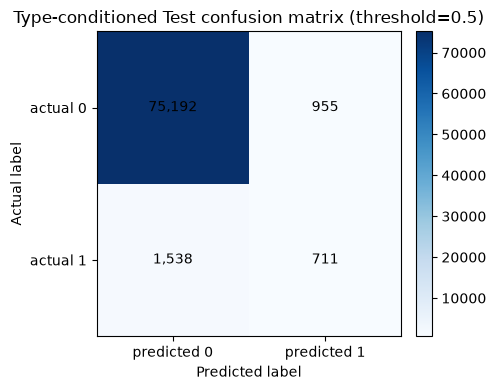

In [11]:
test_df = clean_df.loc[test_mask]
test_probabilities = probabilities_by_split["test"]
test_predictions = (
    test_probabilities >= DECISION_THRESHOLD
).astype("int8")
test_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        test_df[TARGET],
        test_predictions,
        labels=[0, 1],
    ),
    index=["actual_0", "actual_1"],
    columns=["predicted_0", "predicted_1"],
)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(test_confusion_matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(
    test_confusion_matrix.to_numpy()
):
    ax.text(column, row, f"{value:,}", ha="center", va="center")
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["predicted 0", "predicted 1"],
    yticklabels=["actual 0", "actual 1"],
    xlabel="Predicted label",
    ylabel="Actual label",
    title=(
        "Type-conditioned Test confusion matrix "
        f"(threshold={DECISION_THRESHOLD})"
    ),
)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
display(test_confusion_matrix)
plt.show()

## 9. 모델 저장

In [12]:
model_artifact = {
    "models_by_type": models_by_type,
    "feature_columns_by_type": feature_columns_by_type,
    "decision_threshold": DECISION_THRESHOLD,
    "train_end_time": str(train_end_time),
    "validation_end_time": str(valid_end_time),
}
joblib.dump(model_artifact, MODEL_PATH)
print(f"saved: {MODEL_PATH}")

saved: ..\models\0824_kimjaehak_006_type_conditioned_baseline.pkl


## 10. 결론 및 다음 단계

기존 baseline과 동일한 데이터 정리, 시간순 분할, XGBoost 설정 및 threshold 0.5에서 type-conditioned 모델의 Test 결과는 다음과 같습니다.

- Confusion matrix: TN 75,192 / FP 955 / FN 1,538 / TP 711
- Accuracy: 0.968200
- Precision: 0.426771
- Recall: 0.316141
- Specificity: 0.987458
- F1: 0.363218
- ROC-AUC: 0.873366
- PR-AUC: 0.315411

기존 통합 XGBoost baseline보다 전체 PR-AUC, Recall과 F1이 개선됐습니다. 그러나 type 0 Recall은 0.007519이고 type 4 Recall은 0으로 검사유형별 성능 편차가 큽니다. threshold 0.5는 비교용 기준이며 안전한 운영 임계값이 아닙니다. 다음 실험에서는 Test를 사용하지 않고 Validation에서 type별 Recall 제약을 만족하는 threshold를 선택해야 합니다.